# Analisis Exploratorio de Datos

- Base de datos utilizada: excel con datos de pacientes datada de 2022

----------------
## Parte 0: setup y limpieza
----------------

In [36]:
#imports
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from shapely.geometry import box

import sys
sys.path.append("../scripts")  # carpeta donde está bases.py
import bases

In [37]:
# cargar datos
df_pacientes = bases.cargar_datos_pacientes("../data/pacientes.xlsx")
hosp_coord = bases.cargar_coordenadas("../data/hospitales_coordenadas.csv")
df_traslados = bases.reconstruir_traslados(df_pacientes)

In [38]:
'''
# normalizar nombres de hospitales (aseguramos consistencia)
df_traslados["Nombre Hospital"] = df_traslados["Nombre Hospital"].str.strip().str.upper()
df_traslados["Hospital siguiente"] = df_traslados["Hospital siguiente"].str.strip().str.upper()
hosp_coord["Nombre Hospital"] = hosp_coord["Nombre Hospital"].str.strip().str.upper()
'''

'\n# normalizar nombres de hospitales (aseguramos consistencia)\ndf_traslados["Nombre Hospital"] = df_traslados["Nombre Hospital"].str.strip().str.upper()\ndf_traslados["Hospital siguiente"] = df_traslados["Hospital siguiente"].str.strip().str.upper()\nhosp_coord["Nombre Hospital"] = hosp_coord["Nombre Hospital"].str.strip().str.upper()\n'

In [ ]:
# generar red
G, edges, fig_tuple = bases.analizar_red_hospitalaria(
    df_traslados,
    hosp_coord,
    fecha_inicio="2020-06-01",
    fecha_fin="2020-10-31",
    peso_minimo=1,
    modo="estatico",       # "estatico", "mapa" o "interactivo"
    mostrar_resumen=True,
    graficar=False,         # si querés mostrar el gráfico
    mostrar_nombres=True,  # mostrar nombres de hospitales
    mostrar_peso=True      # mostrar pesos de las aristas
)

Registros luego de filtros: 481
Hospitales origen únicos: 12
Hospitales destino únicos: 12
Nodos en red: 13
Aristas en red: 38


In [40]:
# convertir red a GeoDataFrames
gdf_edges, gdf_nodes = bases.gdf_red_hospitalaria(G, hosp_coord)

Ignorados (no encontrados en hosp_coords): {'MODULO HOSPITALARIO    AB'}


#### Contexto geografico - AMBA
1. Descargamos los shapefiles de los departamentos de todo el pais
2. Definimos una caja para usar como cota asi nos aseguramos de tomar departamentos que esten en el AMBA
3. Hacemos la interseccion para filtrar los shapefiles de todos los partidos del AMBA

In [41]:
# cargar shapefiles de municipios para contexto geográfico
municipios = bases.cargar_municipios("../data/shapefiles/departamento/departamentoPolygon.shp")
municipios_amba = municipios[
    municipios["in1"].astype(str).str.startswith(("0"))
]

In [54]:
# filtrar solo partidos del AMBA
amba_partidos_todos = [
    "CIUDAD AUTONOMA DE BUENOS AIRES", "QUILMES", "ALMIRANTE BROWN",
    "FLORENCIO VARELA", "BERAZATEGUI", "LANUS", "LOMAS DE ZAMORA",
    "AVELLANEDA", "ESCOBAR", "MORON", "MARTINEZ", "HURLINGHAM",
    "ITUZAINGO", "LA MATANZA", "TIGRE", "SAN ISIDRO", "VICENTE LOPEZ"
]

amba_partidos = [
    "QUILMES", "ALMIRANTE BROWN",
    "FLORENCIO VARELA", "BERAZATEGUI", "LANUS", "LOMAS DE ZAMORA",
    "AVELLANEDA", "MORON", "ITUZAINGO"
]

municipios_amba = municipios_amba[municipios_amba["nam_limpio"].isin(amba_partidos)]

--------------------------
## Parte 1: mapa de hospitales y municipios
--------------------------

In [8]:
## NO FUNCIONA TODAVIA:

In [55]:
municipios_3857 = municipios_amba.to_crs(epsg=3857)
nodes_3857 = gdf_nodes.to_crs(epsg=3857)
edges_3857 = gdf_edges.to_crs(epsg=3857)

In [56]:
print("municipios:", len(municipios))
print("municipios_amba:", len(municipios_amba))

municipios: 529
municipios_amba: 6


Ignorados (no encontrados en hosp_coords): {'MODULO HOSPITALARIO    AB'}


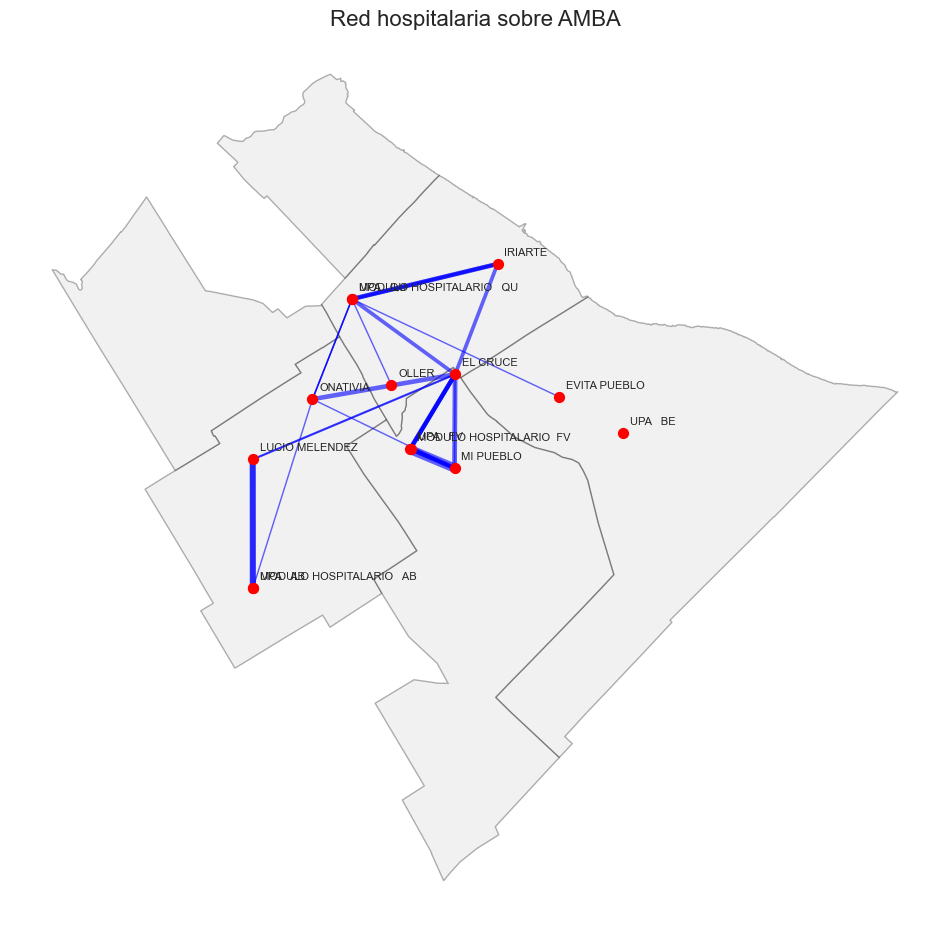

In [57]:
# suponiendo que ya tenés gdf_nodes y municipios_amba listos
# Primero convertimos G y hosp_coord a GeoDataFrames
gdf_edges, gdf_nodes = bases.gdf_red_hospitalaria(G, hosp_coord)

# Plotear sobre los municipios filtrados de AMBA
bases.plot_red_sobre_amba(gdf_edges, gdf_nodes, municipios_amba, mostrar_nombres=True, mostrar_peso=True)

Ignorados (no encontrados en hosp_coords): {'MODULO HOSPITALARIO    AB'}


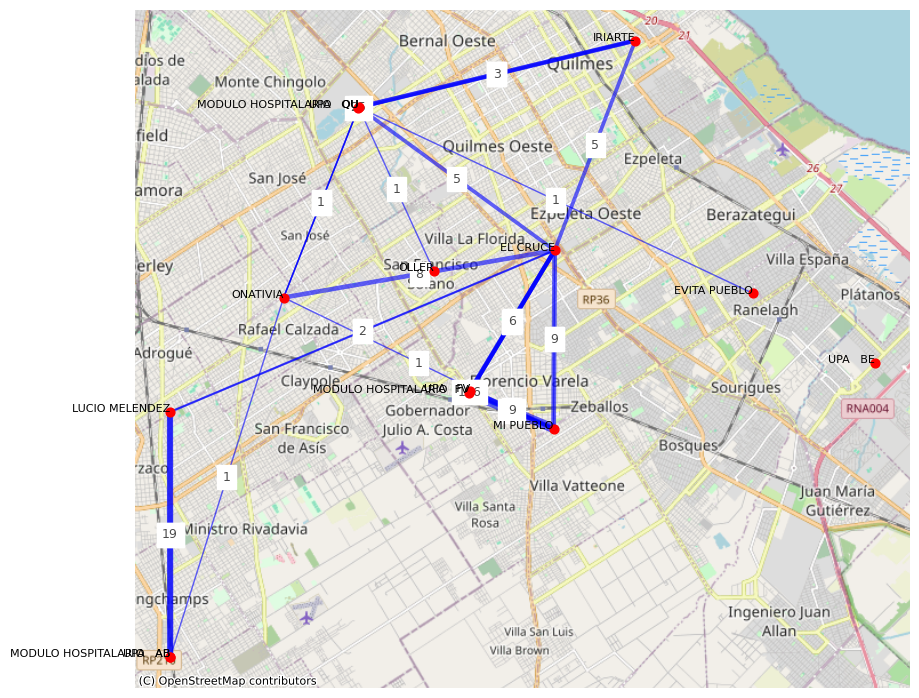

In [12]:
# Convertir G en GeoDataFrames
gdf_edges, gdf_nodes = bases.gdf_red_hospitalaria(G, hosp_coord)

# Ploteamos con opciones
fig, ax = bases.plot_red_gdf(
    G,
    hosp_coord,
    mostrar_nombres=True,
    mostrar_peso=True
)
plt.show()

--------------------------
## Parte 2: métricas agregadas de la red
--------------------------

Total de traslados: 496
Cantidad de hospitales únicos: 12


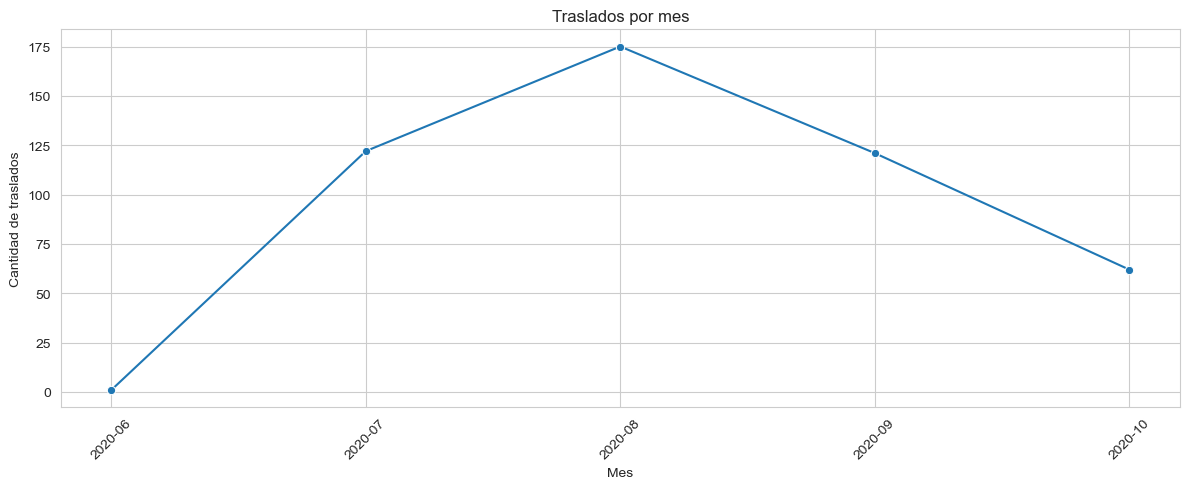

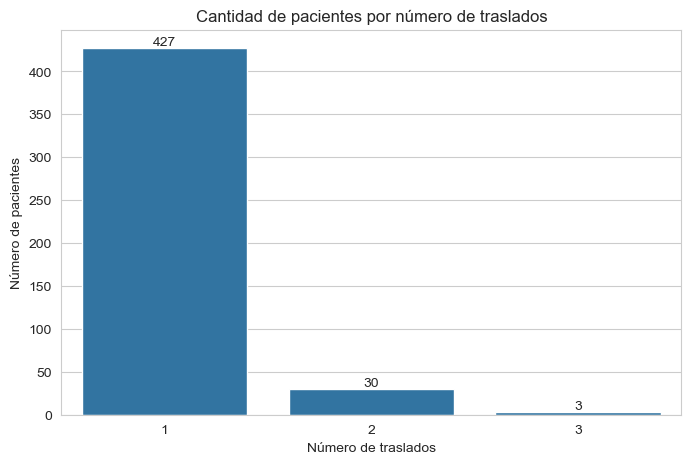

Promedio de traslados por paciente: 1.0782608695652174
Desvío estándar: 0.29217316878347405


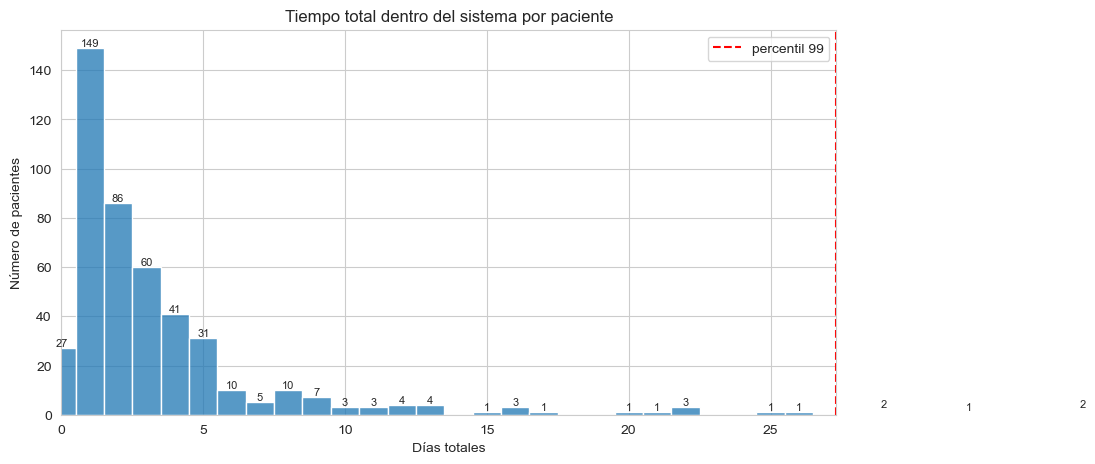

In [13]:
bases.resumen_traslados(df_traslados)

bases.traslados_por_mes(df_traslados)

bases.distribucion_traslados_paciente(df_traslados)

bases.tiempo_total_paciente(df_traslados);

# sns.histplot(tiempo_sistema[tiempo_sistema < 50], bins=20)
# me gusto como se veia ese grafico, re-ver

--------------------------
## Parte 3: métricas por hospital
--------------------------

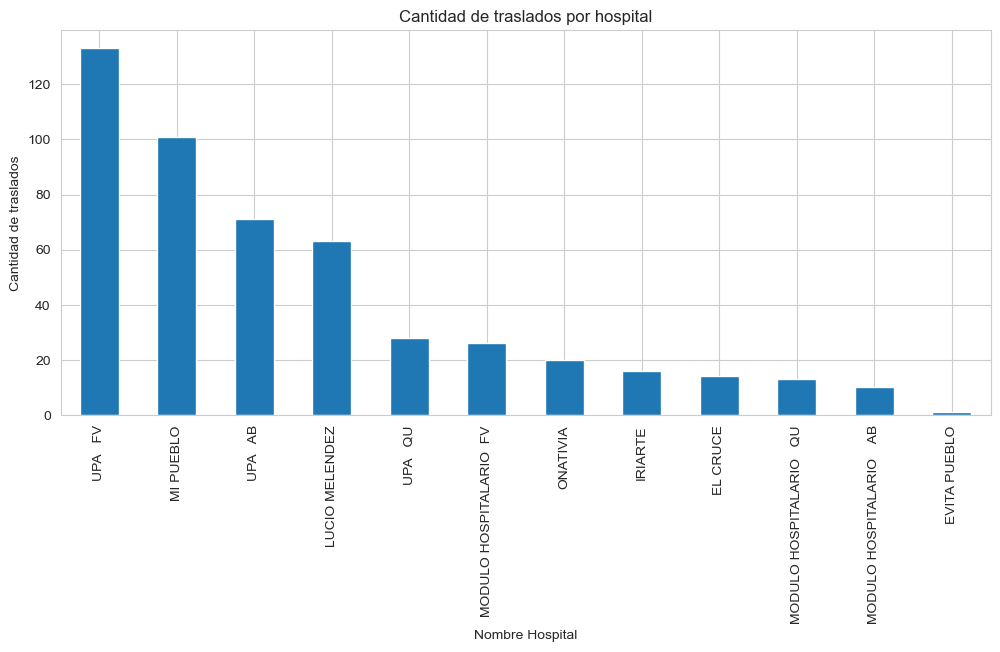

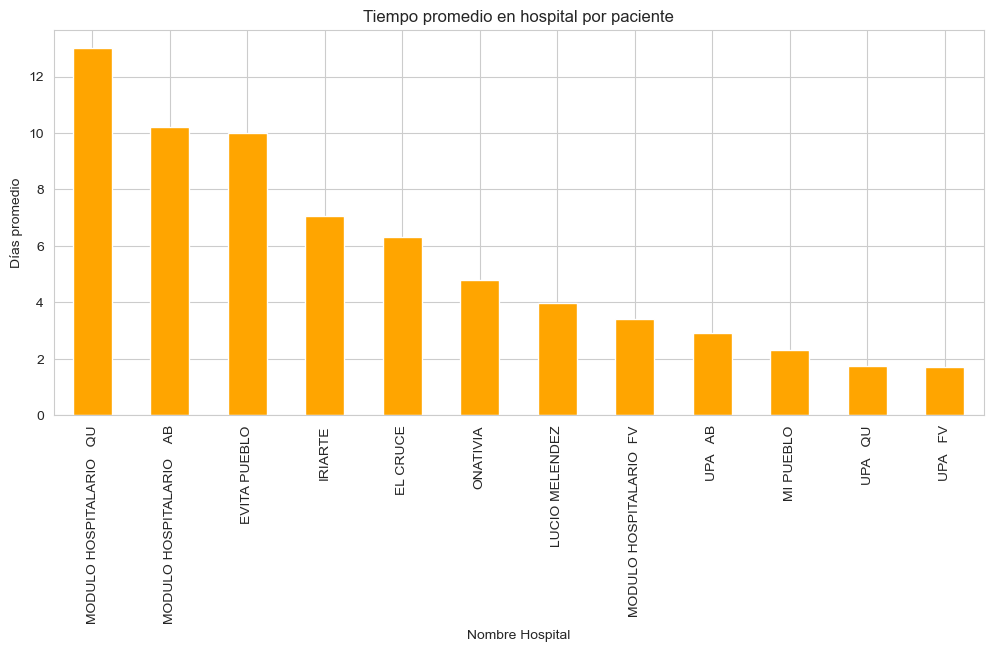

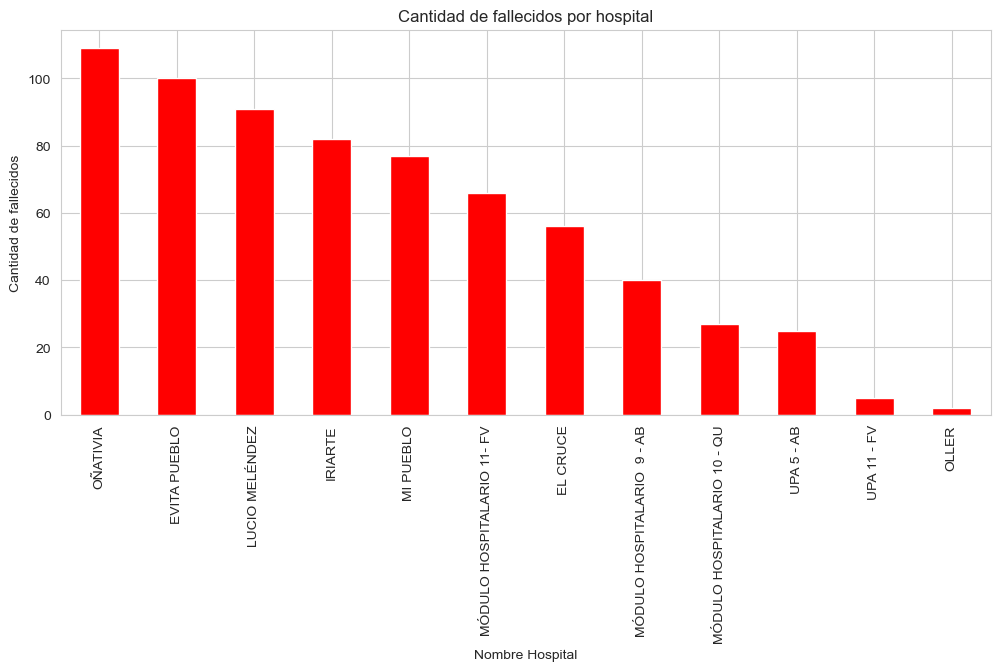

In [14]:
df_pacientes["murio"] = df_pacientes["Motivo"].str.contains("muer|FALLE", na=False)
bases.traslados_por_hospital(df_traslados)

bases.tiempo_promedio_por_hospital(df_traslados)

bases.muertes_por_hospital(df_pacientes);

--------------------------
## Parte 4: riesgo social y estado de pacientes
--------------------------

In [15]:
df_pacientes.columns

Index(['Id Hospital', 'Nombre Hospital', 'Id', 'Fecha inicio',
       'Estado al ingreso', 'Tipo al ingreso', 'Último estado', 'Último tipo',
       'Sexo', 'Edad', 'Nivel riesgo clínico', 'Nivel riesgo social',
       'Enfermedades preexistentes', 'Motivo', 'Operación', 'Fecha egreso',
       'Última actualización', 'Duracion días', 'murio'],
      dtype='str')

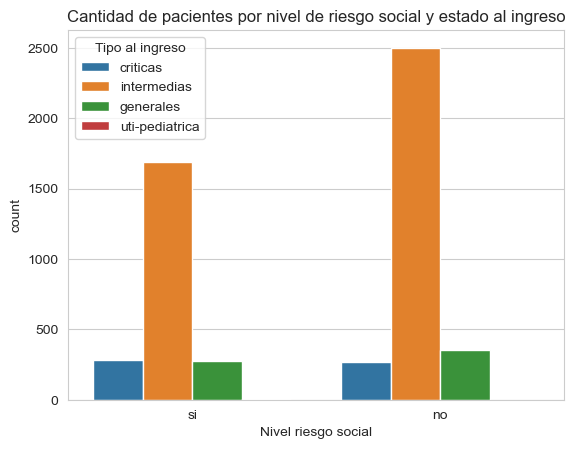

In [16]:
if "Nivel riesgo social" in df_pacientes.columns:
    sns.countplot(x="Nivel riesgo social", hue="Tipo al ingreso", data=df_pacientes)
    plt.title("Cantidad de pacientes por nivel de riesgo social y estado al ingreso")
    plt.show()
else:
    print("No hay columna 'Nivel riesgo social' en los datos")

--------------------------
## Parte 5: métricas extra
--------------------------

In [17]:
# pacientes que pasaron por más de un hospital
multiples_hosp = df_pacientes.groupby("Id")["Nombre Hospital"].nunique()
print("Pacientes que pasaron por más de un hospital:", (multiples_hosp > 1).sum())

Pacientes que pasaron por más de un hospital: 559


## Parte 1: Analisis Exploratorio de los datos

### 1.1.2. Matriz de Distancias: Tabla o heatmap con las distancias en km entre nodos (necesario para validar luego la "distancia recorrida").

Convertimos a coordenadas métricas.

In [18]:
gdf_hosp_m = gdf_hosp.to_crs(epsg=3857)

NameError: name 'gdf_hosp' is not defined

Calcular matriz

In [ ]:
n = len(gdf_hosp_m)

dist_matrix = pd.DataFrame(
    np.zeros((n,n)),
    index=gdf_hosp_m["Nombre Hospital"],
    columns=gdf_hosp_m["Nombre Hospital"]
)

for i, row_i in gdf_hosp_m.iterrows():
    
    for j, row_j in gdf_hosp_m.iterrows():
        
        dist = row_i.geometry.distance(row_j.geometry) / 1000
        
        dist_matrix.loc[
            row_i["Nombre Hospital"],
            row_j["Nombre Hospital"]
        ] = dist

Ver matriz

In [ ]:
dist_matrix.round(2).head()

Heatmap de distancias

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(
    dist_matrix,
    cmap="viridis"
)

plt.title("Distancia entre hospitales (km)")
plt.show()

### 1.1.4. Distribución de tiempos entre hospitales

In [ ]:
dias = traslados["dias_entre_hospitales"]

plt.figure(figsize=(8,5))

dias.hist(bins=20)

plt.title("Distribución de días entre hospitales")
plt.xlabel("Días")
plt.ylabel("Cantidad")

plt.show()

### 1.1.5. Chequeo de errores (tiempos negativos)

In [ ]:
negativos = traslados[traslados["dias_entre_hospitales"] < 0]

print("Cantidad negativos:", len(negativos))

Ver ejemplos

In [ ]:
negativos[[
    "Id",
    "Nombre Hospital",
    "Hospital siguiente",
    "Fecha egreso",
    "Fecha ingreso siguiente",
    "dias_entre_hospitales"
]].head(10)

### 1.1.6. Construcción de red hospitalaria

In [ ]:
G_periodo, edges_periodo = bases.generar_red(
    traslados,
    "2020-06-01",
    "2020-10-31"
)

Metricas basicas

In [ ]:
print("Nodos:", G_periodo.number_of_nodes())
print("Aristas:", G_periodo.number_of_edges())

print("Densidad:", nx.density(G_periodo))
print("Componentes débiles:", nx.number_weakly_connected_components(G_periodo))

Hospitales que más reciben pacientes

In [ ]:
in_strength = dict(G_periodo.in_degree(weight="weight"))

sorted(
    in_strength.items(),
    key=lambda x: x[1],
    reverse=True
)[:5]

Hospitales que más derivan pacientes

In [ ]:
out_strength = dict(G_periodo.out_degree(weight="weight"))

sorted(
    out_strength.items(),
    key=lambda x: x[1],
    reverse=True
)[:5]

Intermediarios de la red

In [ ]:
bet = nx.betweenness_centrality(G_periodo, weight="weight")

sorted(
    bet.items(),
    key=lambda x: x[1],
    reverse=True
)[:5]

### 1.1.7. Visualización de la red

In [ ]:
fig, ax = bases.plot_red_con_mapa(G_periodo, hosp_coords)

m = bases.plot_red_interactiva(G_periodo, hosp_coords)

m

## 1.2. Métricas de Traslados (Flujo General)

In [ ]:
traslados = bases.reconstruir_traslados(df_pacientes)

print("Traslados confirmados:", len(traslados))

#### 1.2.1. Volúmenes Totales

In [ ]:
# total de admisiones
total_admisiones = len(df_pacientes)

# total de traslados detectados
total_traslados = len(traslados)

porcentaje_traslados = total_traslados / total_admisiones * 100

print("Total admisiones:", total_admisiones)
print("Total traslados:", total_traslados)
print("Porcentaje de admisiones que terminan en traslado:", round(porcentaje_traslados,2), "%")

#### 1.2.2. Serie Temporal

In [ ]:
# admisiones por semana
adm_semana = (
    df_pacientes
    .set_index("Fecha inicio")
    .resample("W")
    .size()
)

# traslados por semana
tras_semana = (
    traslados
    .set_index("Fecha egreso")
    .resample("W")
    .size()
)

plt.figure(figsize=(10,5))

plt.plot(adm_semana.index, adm_semana.values, label="Admisiones")
plt.plot(tras_semana.index, tras_semana.values, label="Traslados")

plt.title("Admisiones vs Traslados en el tiempo")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de pacientes")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

#### 1.2.3. Análisis por Paciente

In [ ]:
traslados_por_persona = traslados.groupby("Id").size()

print("Pacientes con al menos un traslado:", len(traslados_por_persona))

Estadística descriptiva

In [ ]:
print("Media:", traslados_por_persona.mean())
print("Desvío estándar:", traslados_por_persona.std())
print("Mediana:", traslados_por_persona.median())
print("Máximo:", traslados_por_persona.max())

Histograma

In [ ]:
plt.figure(figsize=(8,5))

traslados_por_persona.hist(bins=15)

plt.title("Distribución de traslados por paciente")
plt.xlabel("Cantidad de traslados")
plt.ylabel("Número de pacientes")

plt.grid(alpha=0.3)
plt.show()

Boxplot

In [ ]:
plt.figure(figsize=(6,4))

plt.boxplot(traslados_por_persona)

plt.title("Boxplot traslados por paciente")
plt.ylabel("Cantidad de traslados")

plt.show()

## 1.3 Análisis de Permanencia y Riesgo

### 1.3.1 Tiempo total en el sistema

Calculamos para cada paciente: tiempo_sistema = fecha_egreso_final - fecha_ingreso_inicial

In [ ]:
tiempo_sistema = df_pacientes.groupby("Id").agg(
    ingreso_inicial=("Fecha inicio", "min"),
    egreso_final=("Fecha egreso", "max")
)

tiempo_sistema["dias_sistema"] = (
    tiempo_sistema["egreso_final"] -
    tiempo_sistema["ingreso_inicial"]
).dt.days

Histograma de estadía total

In [ ]:
plt.figure(figsize=(8,5))

tiempo_sistema["dias_sistema"].hist(bins=30)

plt.title("Tiempo total en el sistema hospitalario")
plt.xlabel("Días")
plt.ylabel("Cantidad de pacientes")

plt.grid(alpha=0.3)
plt.show()

### 1.3.2. Riesgo social y estado clínico

In [ ]:
print(df_pacientes["Estado al ingreso"].value_counts())
print(df_pacientes["Nivel de riesgo"].value_counts())

Tabla cruzada

In [ ]:
tabla_riesgo_estado = pd.crosstab(
    df_pacientes["Nivel de riesgo"],
    df_pacientes["Estado al ingreso"]
)

print(tabla_riesgo_estado)

Gráfico de barras

In [ ]:
tabla_riesgo_estado.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Nivel de riesgo vs estado clínico al ingreso")
plt.xlabel("Nivel de riesgo")
plt.ylabel("Cantidad de pacientes")

plt.xticks(rotation=0)
plt.legend(title="Estado clínico")

plt.show()

### 1.3.3. Tasa de mortalidad por categoría

In [ ]:
df_pacientes["murio"] = df_pacientes["Motivo"].str.contains("falle", case=False, na=False)

Mortalidad por riesgo

In [ ]:
mortalidad_riesgo = df_pacientes.groupby("Nivel de riesgo")["murio"].mean()

print(mortalidad_riesgo)

Gráfico

In [ ]:
mortalidad_riesgo.plot(kind="bar", figsize=(6,4))

plt.title("Tasa de mortalidad por nivel de riesgo")
plt.ylabel("Probabilidad de muerte")

plt.xticks(rotation=0)
plt.show()

## 1.4. Descriptivos por Nodo (Hospital)

### 1.4.1. Traslados In / Out

In [ ]:
traslados_out = traslados.groupby("Nombre Hospital").size()
traslados_in = traslados.groupby("Hospital siguiente").size()

### 1.4.2. Estadía promedio por hospital

In [ ]:
estadia_promedio = df_pacientes.groupby("Nombre Hospital")["Duracion días"].mean()

### 1.4.3. Mortalidad por hospital

In [ ]:
mortalidad_hospital = df_pacientes.groupby("Nombre Hospital")["murio"].mean()

### 1.4.4. Total de pacientes por hospital

In [ ]:
pacientes_por_hospital = df_pacientes.groupby("Nombre Hospital")["Id"].nunique()

### 1.4.5. Tabla final resumen

In [ ]:
tabla_hospitales = pd.DataFrame({
    "traslados_out": traslados_out,
    "traslados_in": traslados_in,
    "estadia_promedio_dias": estadia_promedio,
    "tasa_mortalidad": mortalidad_hospital,
    "pacientes_distintos": pacientes_por_hospital
}).fillna(0)

tabla_hospitales = tabla_hospitales.sort_values(
    "traslados_in",
    ascending=False
)

tabla_hospitales.head(10)

## Visualizacion

### Hospitales que más reciben pacientes

In [ ]:
tabla_hospitales["traslados_in"].sort_values(ascending=False).head(10).plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Hospitales que más reciben traslados")
plt.ylabel("Cantidad de pacientes")

plt.show()